Titanic dataset loaded successfully!

FIRST 5 ROWS:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



DATASET SHAPE:
(891, 15)

COLUMN NAMES:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

CLEANED COLUMN NAMES:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_ma

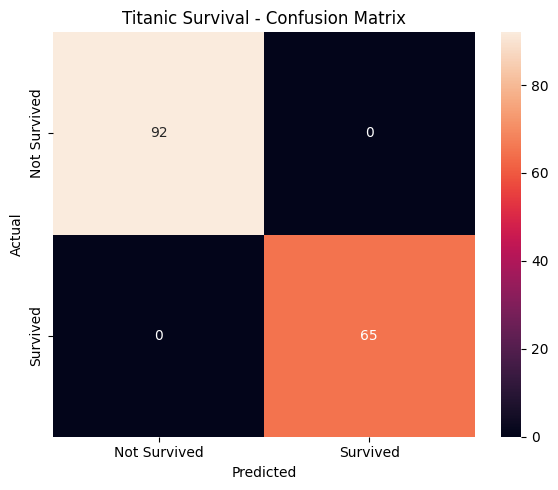


PREDICTION RESULTS:


,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,0,0
9,1,1



PROJECT 5 COMPLETED SUCCESSFULLY!
Titanic Survival — Full Logistic Regression Pipeline

Model Used:
Logistic Regression

Output File:
titanic_logistic_regression_results.csv

File Created:
True

Exact File Location:
C:\Users\monis\titanic_logistic_regression_results.csv



In [1]:
# ============================================================
# PROJECT 5: TITANIC SURVIVAL
# FULL LOGISTIC REGRESSION PIPELINE
#
# Notebook: 05_Titanic_Logistic_Regression.ipynb
# Input:    titanic.csv
# Output:   titanic_logistic_regression_results.csv
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. LOAD TITANIC DATASET
# ============================================================

df = pd.read_csv("titanic.csv")

print("Titanic dataset loaded successfully!")


# ============================================================
# 3. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFIRST 5 ROWS:")

display(df.head())


# ============================================================
# 4. DATASET SHAPE
# ============================================================

print("\nDATASET SHAPE:")

print(df.shape)


# ============================================================
# 5. COLUMN NAMES
# ============================================================

print("\nCOLUMN NAMES:")

print(df.columns.tolist())


# ============================================================
# 6. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
)


print("\nCLEANED COLUMN NAMES:")

print(df.columns.tolist())


# ============================================================
# 7. DATASET INFORMATION
# ============================================================

print("\nDATASET INFORMATION:")

df.info()


# ============================================================
# 8. MISSING VALUES
# ============================================================

print("\nMISSING VALUES:")

print(df.isnull().sum())


# ============================================================
# 9. REMOVE DUPLICATE ROWS
# ============================================================

duplicate_rows = df.duplicated().sum()

print("\nDUPLICATE ROWS:", duplicate_rows)

df = df.drop_duplicates()


# ============================================================
# 10. IDENTIFY TARGET COLUMN
# ============================================================

if "survived" not in df.columns:
    raise ValueError(
        "Target column 'survived' was not found in titanic.csv"
    )


X = df.drop(
    "survived",
    axis=1
)

y = df["survived"]


print("\nTARGET COLUMN: survived")


# ============================================================
# 11. DROP UNNECESSARY / HIGH-CARDINALITY COLUMNS
# ============================================================

columns_to_drop = [
    "name",
    "ticket",
    "cabin",
    "boat",
    "body",
    "home.dest"
]


existing_columns = [
    column
    for column in columns_to_drop
    if column in X.columns
]


X = X.drop(
    columns=existing_columns
)


print("\nDROPPED COLUMNS:")

print(existing_columns)


# ============================================================
# 12. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()


categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNUMERICAL COLUMNS:")

print(numerical_columns)


print("\nCATEGORICAL COLUMNS:")

print(categorical_columns)


# ============================================================
# 13. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTRAINING DATA SHAPE:")

print(X_train.shape)


print("\nTESTING DATA SHAPE:")

print(X_test.shape)


# ============================================================
# 14. NUMERICAL PREPROCESSING PIPELINE
# ============================================================

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 15. CATEGORICAL PREPROCESSING PIPELINE
# ============================================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# 16. COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)


# ============================================================
# 17. CREATE FULL MACHINE LEARNING PIPELINE
# ============================================================

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


print("\nFull preprocessing and Logistic Regression pipeline created!")


# ============================================================
# 18. TRAIN THE MODEL
# ============================================================

model.fit(
    X_train,
    y_train
)


print("\nLogistic Regression model trained successfully!")


# ============================================================
# 19. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)


print("\nPredictions completed successfully!")


# ============================================================
# 20. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n==============================================")
print("MODEL EVALUATION")
print("==============================================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX:")

print(cm)


# ============================================================
# 23. CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(
    figsize=(6, 5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Not Survived",
        "Survived"
    ],
    yticklabels=[
        "Not Survived",
        "Survived"
    ]
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "Titanic Survival - Confusion Matrix"
)


plt.tight_layout()

plt.show()


# ============================================================
# 24. CREATE PREDICTION RESULTS DATASET
# ============================================================

results = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Predicted": y_pred
    }
)


print("\nPREDICTION RESULTS:")

display(
    results.head(10)
)


# ============================================================
# 25. SAVE RESULTS
# ============================================================

output_file = "titanic_logistic_regression_results.csv"


results.to_csv(
    output_file,
    index=False
)


# ============================================================
# 26. VERIFY FILE CREATION
# ============================================================

print("\n==============================================")
print("PROJECT 5 COMPLETED SUCCESSFULLY!")
print("Titanic Survival — Full Logistic Regression Pipeline")
print("==============================================")

print("\nModel Used:")
print("Logistic Regression")

print("\nOutput File:")
print(output_file)

print("\nFile Created:")
print(
    os.path.exists(output_file)
)

print("\nExact File Location:")
print(
    os.path.abspath(output_file)
)

print("\n==============================================")